# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [2]:
%pip install pandas numpy matplotlib seaborn scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\huynh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
#lấy file về máy
df.to_csv('insurance.csv',index = False)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [4]:
# TODO
print("Data size: ", df.shape)
print("\nColumn name: \n",df.columns)
print("\nData types: \n", df.dtypes)

Data size:  (1338, 7)

Column name: 
 Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

Data types: 
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


## A.2. Missing values & Duplicate data

In [5]:
# TODO
print("Dữ liệu bị mất:\n",df.isnull().sum())
print("\nDữ liệu bị trùng lặp: ", df.duplicated().sum())

Dữ liệu bị mất:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Dữ liệu bị trùng lặp:  1


## A.3. Invalid values

In [6]:
# TODO
df_clean = df[
(df['age'] > 0) & (df['age'] <120) &
(df['sex'].isin(['male','female'])) &
(df['bmi'] >= 10) & (df['bmi'] <= 70)&
(df['children'] >= 0) &
(df['smoker'].isin(['yes','no'])) &
(df['charges'] > 0)
]

df_clean.to_csv('insurance.csv', index = False)

## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [7]:
# TODO
dieukien = [
    df_clean['bmi'] < 25,
    (df_clean['bmi'] >= 25) & (df_clean['bmi'] < 30),
    df_clean['bmi'] >= 30
]

choices = ['Normal', 'Overweight', 'Obese']

df_clean['bmi_group'] = np.select(dieukien, choices, default= 'Unknown')
df_clean[['bmi','bmi_group']].head(100)


,bmi,bmi_group
0,27.900,Overweight
1,33.770,Obese
2,33.000,Obese
3,22.705,Normal
4,28.880,Overweight
...,...,...
95,37.620,Obese
96,30.800,Obese
97,38.280,Obese
98,19.950,Normal


In [8]:
df_clean[['bmi','age']]

,bmi,age
0,27.900,19
1,33.770,18
2,33.000,28
3,22.705,33
4,28.880,32
...,...,...
1333,30.970,50
1334,31.920,18
1335,36.850,18
1336,25.800,21


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [9]:
# TODO
df_clean.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Group 2 — Dispersion

In [10]:
# TODO
range = df_clean['charges'].max() - df_clean['charges'].min()
#độ lệch chuẩn
std = df_clean['charges'].std()
#phương sai
var = df_clean['charges'].var()

print("Khoảng: ",range)
print("Độ lệch chuẩn: ",std)
print("Phương sai: ",var)

#khoảng tứ phân vị

Q1 = df_clean['charges'].quantile(0.25)
Q3 = df_clean['charges'].quantile(0.75)

IQR = Q3- Q1
print("Khoảng tứ phân vị: ", IQR)

Khoảng:  62648.554110000005
Độ lệch chuẩn:  12110.011236694001
Phương sai:  146652372.15285498
Khoảng tứ phân vị:  11899.625365


## Group 3 — Location and Shape

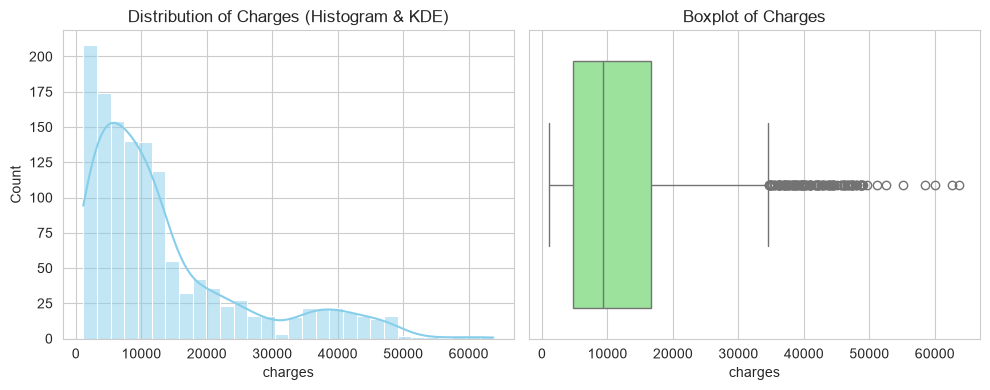

In [11]:
# TODO
# Location
mean_val = df_clean['charges'].mean()
median_val = df_clean['charges'].median()
mode_val = df_clean['charges'].mode()[0]

# Shape
plt.figure(figsize=(10, 4))

# 1. Histogram + KDE
plt.subplot(1, 2, 1)
sns.histplot(df_clean['charges'], kde=True, color='skyblue')
plt.title('Distribution of Charges (Histogram & KDE)')

# 2. Boxplot (xem vị trí trung tâm + ngoại lệ)
plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean['charges'], color='lightgreen')
plt.title('Boxplot of Charges')

plt.tight_layout()
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

In [12]:
# TODO

# Tính tỷ lệ chi phí chung giữa người hút thuốc và không hút thuốc
tb_chi_phi_hut_thuoc = df_clean.groupby('smoker')['charges'].mean()
tile = tb_chi_phi_hut_thuoc['yes'] / tb_chi_phi_hut_thuoc['no']
print("Ti le tra chi phi giua nguoi hut thuoc so voi khong nguoi hut thuoc la",tile)

print("Nhận xét: người hút thuốc phải trả chi phí cao hơn người không hút thuốc là 3.8")

# So sánh tỷ lệ này theo từng vùng
region_smoker = df_clean.groupby(['region', 'smoker'])['charges'].mean().unstack()
region_smoker['ty_le'] = region_smoker['yes'] / region_smoker['no']
print("\nChi phí trung bình và tỷ lệ theo vùng:\n", region_smoker)

print("Nhận xét: tỉ lệ hút thuốc và không hút thuốc không được phân bố đồng đều giữa các vùng")


Ti le tra chi phi giua nguoi hut thuoc so voi khong nguoi hut thuoc la 3.800001458298319
Nhận xét: người hút thuốc phải trả chi phí cao hơn người không hút thuốc là 3.8

Chi phí trung bình và tỷ lệ theo vùng:
 smoker              no           yes     ty_le
region                                        
northeast  9165.531672  29673.536473  3.237514
northwest  8556.463715  30192.003182  3.528561
southeast  8032.216309  34844.996824  4.338155
southwest  8019.284513  32269.063494  4.023933
Nhận xét: tỉ lệ hút thuốc và không hút thuốc không được phân bố đồng đều giữa các vùng


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

In [13]:
# TODO

# Tính hệ số tương quan giữa BMI và Charges cho 2 nhóm
corr_smoker = df_clean[df_clean['smoker'] == 'yes']['bmi'].corr(df_clean[df_clean['smoker'] == 'yes']['charges'])
corr_nonsmoker = df_clean[df_clean['smoker'] == 'no']['bmi'].corr(df_clean[df_clean['smoker'] == 'no']['charges'])

print(f"Hệ số tương quan BMI & Charges (Người hút thuốc): {corr_smoker:.2f}")
print(f"Hệ số tương quan BMI & Charges (Người không hút thuốc): {corr_nonsmoker:.2f}")


Hệ số tương quan BMI & Charges (Người hút thuốc): 0.81
Hệ số tương quan BMI & Charges (Người không hút thuốc): 0.08


## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [14]:
# TODO

# Tính chi phí bảo hiểm trung bình theo vùng và sắp xếp giảm dần
region_avg = df_clean.groupby('region')['charges'].mean().sort_values(ascending=False)
print("Chi phí bảo hiểm trung bình theo vùng:\n", region_avg)

Chi phí bảo hiểm trung bình theo vùng:
 region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

In [15]:
# TODO
# Tính chi phí trung bình theo số lượng con và hệ số tương quan
children_avg = df_clean.groupby('children')['charges'].mean()
corr_children = df_clean['children'].corr(df_clean['charges'])

print("Chi phí trung bình theo số con:\n", children_avg)
print(f"Hệ số tương quan giữa số con và chi phí: {corr_children:.2f}")

print("Kết quả: Số lượng con cái hầu như không làm tăng chi phí bảo hiểm (hệ số tương quan $r \approx 0.07$ rất yếu). Chi phí chỉ tăng nhẹ ở nhóm 2–3 con, nhưng lại giảm ở nhóm 4–5 con.")


Chi phí trung bình theo số con:
 children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64
Hệ số tương quan giữa số con và chi phí: 0.07
Kết quả: Số lượng con cái hầu như không làm tăng chi phí bảo hiểm (hệ số tương quan $r pprox 0.07$ rất yếu). Chi phí chỉ tăng nhẹ ở nhóm 2–3 con, nhưng lại giảm ở nhóm 4–5 con.


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

In [16]:
# TODO
# Tính hệ số tương quan giữa tuổi và chi phí bảo hiểm
corr_age = df_clean['age'].corr(df_clean['charges'])
print(f"Hệ số tương quan giữa Tuổi và Chi phí: {corr_age:.2f}")

print("Kết quả: Tuổi có tương quan thuận vừa phải với chi phí bảo hiểm ($r \approx 0.30$). Tuổi càng cao thì phí bảo hiểm có xu hướng tăng dần theo thời gian.")

Hệ số tương quan giữa Tuổi và Chi phí: 0.30
Kết quả: Tuổi có tương quan thuận vừa phải với chi phí bảo hiểm ($r pprox 0.30$). Tuổi càng cao thì phí bảo hiểm có xu hướng tăng dần theo thời gian.


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*(Viết insight của bạn vào đây...)*
Hút thuốc là yếu tố ảnh hưởng mạnh nhất: Chi phí bảo hiểm của người hút thuốc cao gấp 3.8 lần người không hút, và sự chênh lệch này diễn ra rõ rệt ở tất cả các vùng.

Sự kết hợp giữa Hút thuốc và BMI tạo ra chi phí đột biến: Ở nhóm hút thuốc, chỉ số BMI có tương quan rất mạnh (r≈0.81) với chi phí; những người vừa béo phì vừa hút thuốc phải trả mức phí cao vượt trội.

Yếu tố tuổi tác có tác động ổn định: Tuổi có tương quan thuận vừa phải (r≈0.30), cho thấy mức phí bảo hiểm tăng dần đều theo độ tuổi của người tham gia.

Vùng miền và số con cái ít tác động độc lập: Số lượng con cái (r≈0.07) không làm tăng đáng kể chi phí bảo hiểm; khu vực Southeast có chi phí trung bình cao nhất chủ yếu do tỷ lệ hút thuốc và BMI ở khu vực này cao hơn.